# Access the analysis ready CAMS Europe air quality reanalyses data

This notebook provides an example of how to open the cams-europe-air-quality-reanalyses Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://ads.atmosphere.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDS API key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDS API key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Geo-chunked data (optimised for time-series at a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-001/arco/cams_europe_air_quality_reanalyses/vra-ens-sfc/geoChunked.zarr"

# Time-chunked data (optimised for map at a single time step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-001/arco/cams_europe_air_quality_reanalyses/vra-ens-sfc/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    geochunked_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 1TB
Dimensions:    (time: 96408, latitude: 420, longitude: 700)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2013-01-01 ... 2023-12-31T23:00:00
  * latitude   (latitude) float64 3kB 30.05 30.15 30.25 ... 71.75 71.85 71.95
  * longitude  (longitude) float64 6kB -24.95 -24.85 -24.75 ... 44.85 44.95
Data variables:
    pm2p5      (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    pm10       (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    no2        (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    so2        (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    o3         (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    Production:   COPERNICUS Atmosphere Monitoring Service
    Provider:     COPERNICUS European air quality service
    Title:        CAMS European air quality validated reanalysis

Extract a point and plot a time-series of PM2.5 concentration using earthkit-plots.

/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/ipykernel_58279/1148720638.py:9: UserWarning: TimeSeries is an experimental new feature in earthkit-plots. We welcome feedback and bug reports on GitHub issues: https://github.com/ecmwf/earthkit-plots/issues
  chart = ekp.TimeSeries()
/Users/edwardcomyn-platt/Work/Git_Repositories/ecmwf-projects/dss-jupyterhub-notebooks/dss-notebooks/.venv/lib/python3.12/site-packages/earthkit/plots/components/subplots.py:1213: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax.legend(*args, **kwargs)


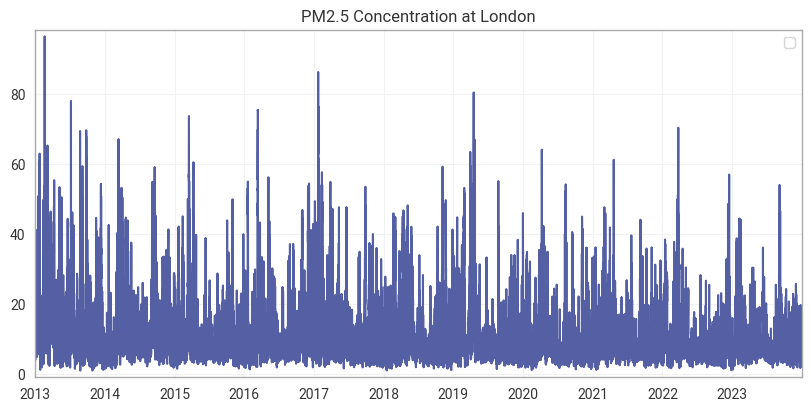

In [3]:
from earthkit import plots as ekp

# Select variable to plot
variable_name = "pm2p5"
plot_data = ds[variable_name].sel(
    latitude=51.5, longitude=-0.1, method="nearest"
)

chart = ekp.TimeSeries()

chart.line(plot_data)

chart.title("PM2.5 Concentration at London")
chart.legend()

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked data (optimised for time-series at a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-001/arco/cams_europe_air_quality_reanalyses/vra-ens-sfc/geoChunked.zarr"

# Time-chunked data (optimised for map at a single time step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-001/arco/cams_europe_air_quality_reanalyses/vra-ens-sfc/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


<xarray.Dataset> Size: 1TB
Dimensions:    (time: 96408, latitude: 420, longitude: 700)
Coordinates:
  * time       (time) datetime64[ns] 771kB 2013-01-01 ... 2023-12-31T23:00:00
  * latitude   (latitude) float64 3kB 30.05 30.15 30.25 ... 71.75 71.85 71.95
  * longitude  (longitude) float64 6kB -24.95 -24.85 -24.75 ... 44.85 44.95
Data variables:
    pm2p5      (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    pm10       (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    no2        (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    so2        (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
    o3         (time, latitude, longitude) float64 227GB dask.array<chunksize=(16896, 8, 8), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    Production:   COPERNICUS Atmosphere Monitoring Service
    Provider:     COPERNICUS European air quality service
    Title:        CAMS European air quality validated reanalysis

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.